In [105]:
# ==========================================
# Food Delivery Time Prediction Project
# Step 1 : Import Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [106]:
# ==========================================
# Step 2 : Load Dataset
# ==========================================

df = pd.read_csv("train.csv")

In [107]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [108]:
df.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36


In [109]:
df.shape

(45593, 20)

In [110]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [112]:
df.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [113]:
# Check missing values
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [114]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [115]:
df.dtypes

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object

In [116]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            0.0
Delivery_person_Ratings        0.0
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Order_Date                     0.0
Time_Orderd                    0.0
Time_Order_picked              0.0
Weatherconditions              0.0
Road_traffic_density           0.0
Vehicle_condition              0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
multiple_deliveries            0.0
Festival                       0.0
City                           0.0
Time_taken(min)                0.0
dtype: float64

In [117]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


ID
<ArrowStringArray>
['0x4607 ', '0xb379 ', '0x5d6d ', '0x7a6a ', '0x70a2 ', '0x9bb4 ', '0x95b4 ',
 '0x9eb2 ', '0x1102 ', '0xcdcd ',
 ...
 '0x5193 ', '0xa333 ', '0xc9ab ', '0x4e21 ', '0x1178 ', '0x7c09 ', '0xd641 ',
 '0x4f8d ', '0x5eee ', '0x5fb2 ']
Length: 45593, dtype: str

Delivery_person_ID
<ArrowStringArray>
[  'INDORES13DEL02 ',   'BANGRES18DEL02 ',   'BANGRES19DEL01 ',
  'COIMBRES13DEL02 ',   'CHENRES12DEL01 ',    'HYDRES09DEL03 ',
 'RANCHIRES15DEL01 ',    'MYSRES15DEL02 ',    'HYDRES05DEL02 ',
    'DEHRES17DEL01 ',
 ...
    'KNPRES18DEL01 ',    'BHPRES08DEL03 ',   'AURGRES13DEL01 ',
   'LUDHRES03DEL02 ',    'KNPRES05DEL01 ',    'GOARES01DEL03 ',
    'KOCRES08DEL03 ',    'KOCRES04DEL01 ',    'BHPRES06DEL03 ',
    'GOARES03DEL03 ']
Length: 1320, dtype: str

Delivery_person_Age
<ArrowStringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39',   '30',   '15',   '50'

In [118]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [119]:
# Create a copy of the original dataset
data = df.copy()

In [120]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Display column names
data.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')

In [121]:
data["Delivery_person_Age"] = pd.to_numeric(data["Delivery_person_Age"], errors="coerce")

data["Delivery_person_Ratings"] = pd.to_numeric(data["Delivery_person_Ratings"], errors="coerce")

data["multiple_deliveries"] = pd.to_numeric(data["multiple_deliveries"], errors="coerce")

In [122]:
data["Time_taken(min)"].head()

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: str

In [123]:
data["Time_taken(min)"].dtype

<StringDtype(na_value=nan)>

In [124]:
# Check missing values
data.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                       0
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [125]:
# Display only columns with missing values
data.isnull().sum()[data.isnull().sum() > 0]

Delivery_person_Age        1854
Delivery_person_Ratings    1908
multiple_deliveries         993
dtype: int64

In [126]:
# Fill missing values with median

data["Delivery_person_Age"] = data["Delivery_person_Age"].fillna(
    data["Delivery_person_Age"].median()
)

data["Delivery_person_Ratings"] = data["Delivery_person_Ratings"].fillna(
    data["Delivery_person_Ratings"].median()
)

data["multiple_deliveries"] = data["multiple_deliveries"].fillna(
    data["multiple_deliveries"].median()
)

In [127]:
data.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [128]:
# Convert Order_Date to datetime format
data["Order_Date"] = pd.to_datetime(data["Order_Date"], dayfirst=True)

In [129]:
# Extract date-related features
data["Order_Day"] = data["Order_Date"].dt.day
data["Order_Month"] = data["Order_Date"].dt.month
data["Order_Weekday"] = data["Order_Date"].dt.day_name()

In [130]:
data[["Order_Date", "Order_Day", "Order_Month", "Order_Weekday"]].head()

,Order_Date,Order_Day,Order_Month,Order_Weekday
0,2022-03-19,19,3,Saturday
1,2022-03-25,25,3,Friday
2,2022-03-19,19,3,Saturday
3,2022-04-05,5,4,Tuesday
4,2022-03-26,26,3,Saturday


In [131]:
from math import radians, sin, cos, sqrt, atan2

In [132]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [133]:
data["Distance_km"] = data.apply(
    lambda row: haversine(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

In [134]:
data[[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Distance_km"
]].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km
0,22.745049,75.892471,22.765049,75.912471,3.025149
1,12.913041,77.683237,13.043041,77.813237,20.183530
2,12.914264,77.678400,12.924264,77.688400,1.552758
3,11.003669,76.976494,11.053669,77.026494,7.790401
4,12.972793,80.249982,13.012793,80.289982,6.210138


In [135]:
data[["Time_Orderd", "Time_Order_picked"]].head()

,Time_Orderd,Time_Order_picked
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00


In [136]:
# Convert time columns to datetime format
data["Time_Orderd"] = pd.to_datetime(data["Time_Orderd"], format="%H:%M:%S")
data["Time_Order_picked"] = pd.to_datetime(data["Time_Order_picked"], format="%H:%M:%S")

ValueError: time data "NaN " doesn't match format "%H:%M:%S". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [137]:
(data["Time_Orderd"] == "NaN ").sum()

np.int64(1731)

In [138]:
(data["Time_Order_picked"] == "NaN ").sum()

np.int64(0)

In [139]:
import numpy as np

data["Time_Orderd"] = data["Time_Orderd"].replace("NaN ", np.nan)

In [140]:
data["Time_Orderd"].isnull().sum()

np.int64(1731)

In [141]:
data["Time_Orderd"] = data["Time_Orderd"].fillna(
    data["Time_Orderd"].mode()[0]
)

In [142]:
data["Time_Orderd"] = pd.to_datetime(
    data["Time_Orderd"],
    format="%H:%M:%S"
)

data["Time_Order_picked"] = pd.to_datetime(
    data["Time_Order_picked"],
    format="%H:%M:%S"
)

In [143]:
# Order Hour
data["Order_Hour"] = data["Time_Orderd"].dt.hour

# Restaurant preparation time
data["Pickup_Time_Minutes"] = (
    data["Time_Order_picked"] - data["Time_Orderd"]
).dt.total_seconds() / 60

In [144]:
data[[
    "Time_Orderd",
    "Time_Order_picked",
    "Order_Hour",
    "Pickup_Time_Minutes"
]].head()

,Time_Orderd,Time_Order_picked,Order_Hour,Pickup_Time_Minutes
0,1900-01-01 11:30:00,1900-01-01 11:45:00,11,15.0
1,1900-01-01 19:45:00,1900-01-01 19:50:00,19,5.0
2,1900-01-01 08:30:00,1900-01-01 08:45:00,8,15.0
3,1900-01-01 18:00:00,1900-01-01 18:10:00,18,10.0
4,1900-01-01 13:30:00,1900-01-01 13:45:00,13,15.0


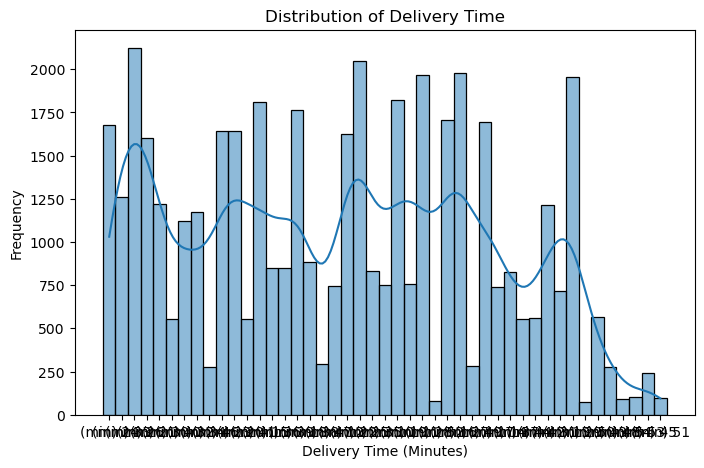

In [145]:
# Graph 1: Distribution of Delivery Time (Target Variable)

plt.figure(figsize=(8,5))
sns.histplot(data["Time_taken(min)"], bins=30, kde=True)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")

plt.show()

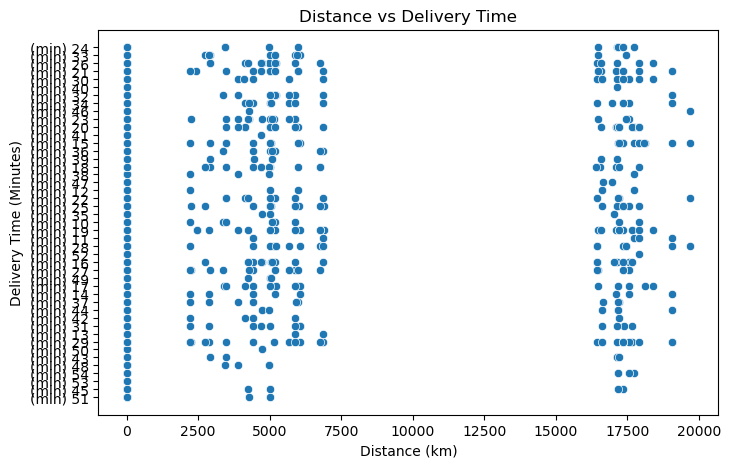

In [146]:
# Graph 2: Delivery Time vs Distance

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=data["Distance_km"],
    y=data["Time_taken(min)"]
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

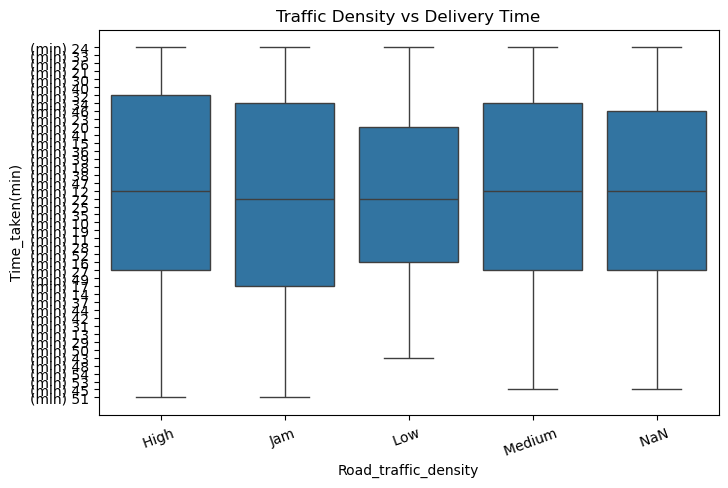

In [147]:
# Graph 3: Traffic Density vs Delivery Time

plt.figure(figsize=(8,5))

sns.boxplot(
    x=data["Road_traffic_density"],
    y=data["Time_taken(min)"]
)

plt.title("Traffic Density vs Delivery Time")
plt.xticks(rotation=20)

plt.show()

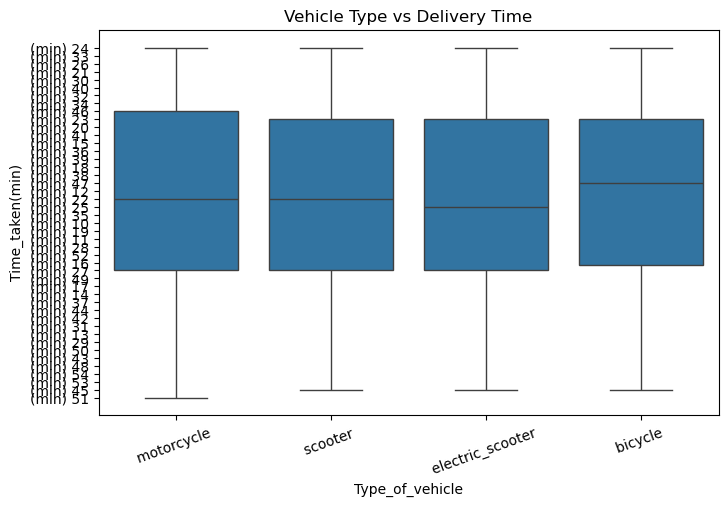

In [148]:
# Graph 4: Vehicle Type vs Delivery Time

plt.figure(figsize=(8,5))

sns.boxplot(
    x=data["Type_of_vehicle"],
    y=data["Time_taken(min)"]
)

plt.title("Vehicle Type vs Delivery Time")
plt.xticks(rotation=20)

plt.show()

In [149]:
# Graph 5: Correlation Heatmap

numeric_data = data.select_dtypes(include=["number"])

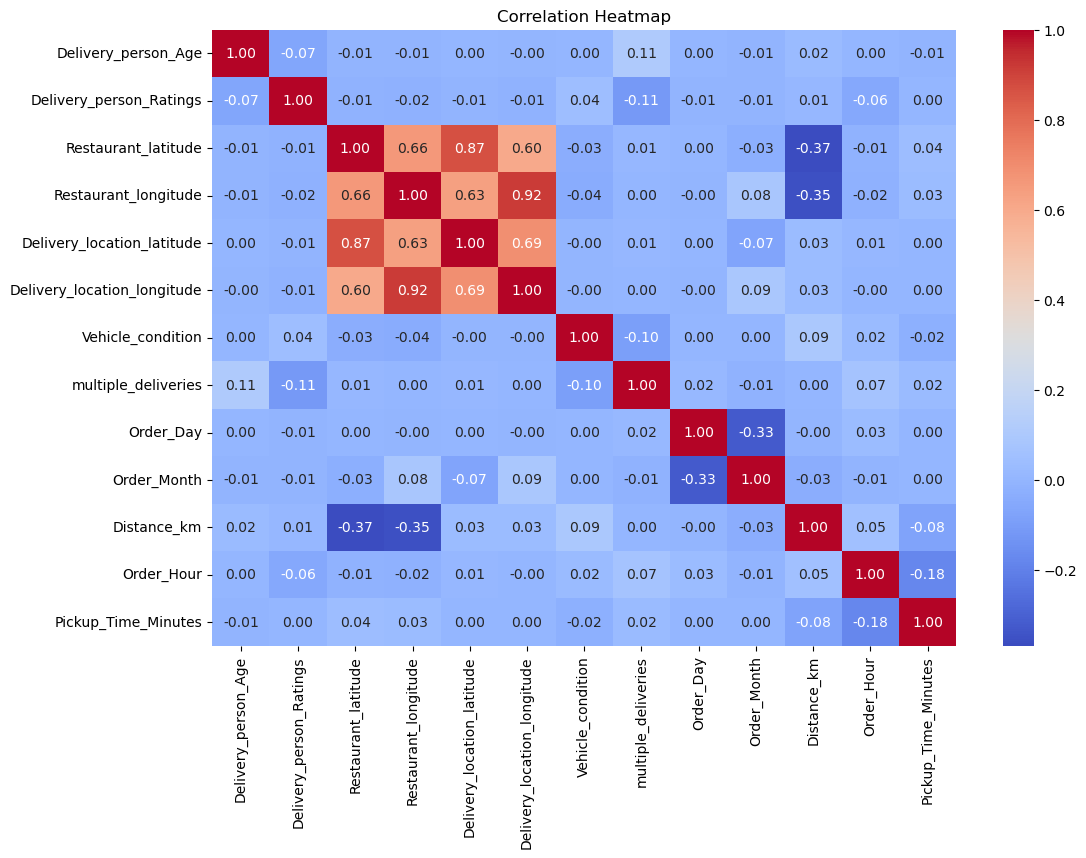

In [150]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [151]:
data = data.drop(columns=[
    "ID",
    "Delivery_person_ID",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked"
])

data.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,multiple_deliveries,Festival,City,Time_taken(min),Order_Day,Order_Month,Order_Weekday,Distance_km,Order_Hour,Pickup_Time_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,conditions Sunny,High,2,Snack,...,0.0,No,Urban,(min) 24,19,3,Saturday,3.025149,11,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,conditions Stormy,Jam,2,Snack,...,1.0,No,Metropolitian,(min) 33,25,3,Friday,20.183530,19,5.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,conditions Sandstorms,Low,0,Drinks,...,1.0,No,Urban,(min) 26,19,3,Saturday,1.552758,8,15.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,conditions Sunny,Medium,0,Buffet,...,1.0,No,Metropolitian,(min) 21,5,4,Tuesday,7.790401,18,10.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,conditions Cloudy,High,1,Snack,...,1.0,No,Metropolitian,(min) 30,26,3,Saturday,6.210138,13,15.0


In [152]:
categorical_cols = data.select_dtypes(include="object").columns
numerical_cols = data.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City', 'Time_taken(min)',
       'Order_Weekday'],
      dtype='str')

Numerical Columns:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Order_Day', 'Order_Month', 'Distance_km',
       'Order_Hour', 'Pickup_Time_Minutes'],
      dtype='str')


In [153]:
from sklearn.preprocessing import LabelEncoder

In [154]:
le = LabelEncoder()

In [155]:
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [156]:
data.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,multiple_deliveries,Festival,City,Time_taken(min),Order_Day,Order_Month,Order_Weekday,Distance_km,Order_Hour,Pickup_Time_Minutes
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,5,0,2,3,...,0.0,1,3,14,19,3,2,3.025149,11,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,1,2,3,...,1.0,1,0,23,25,3,0,20.183530,19,5.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,3,2,0,1,...,1.0,1,3,16,19,3,2,1.552758,8,15.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,5,3,0,0,...,1.0,1,0,11,5,4,5,7.790401,18,10.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,...,1.0,1,0,20,26,3,2,6.210138,13,15.0


In [157]:
# Features
X = data.drop("Time_taken(min)", axis=1)

# Target
y = data["Time_taken(min)"]

In [158]:
print(X.shape)
print(y.shape)

(45593, 20)
(45593,)


In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [160]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (36474, 20)
Testing Data  : (9119, 20)


In [161]:
from sklearn.preprocessing import StandardScaler

In [162]:
scaler = StandardScaler()

In [163]:
X_train_scaled = scaler.fit_transform(X_train)

In [164]:
X_test_scaled = scaler.transform(X_test)

In [165]:
from sklearn.linear_model import LinearRegression

In [166]:
lr = LinearRegression()

In [167]:
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 2.14,-2.41,-0.32,...,-0.39, 1.48, 0.69]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,16.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[343.81,230. ,222.49,...,138.17, 44.71, 4.52]"


In [168]:
y_pred_lr = lr.predict(X_test_scaled)

In [169]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [170]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 5.548310533341438
MSE : 48.156617319948936
RMSE: 6.9394969068333
R² Score: 0.450756834980374


In [171]:
from sklearn.tree import DecisionTreeRegressor

In [172]:
dt = DecisionTreeRegressor(
    random_state=42
)

In [173]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [174]:
y_pred_dt = dt.predict(X_test)

In [175]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("----------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

Decision Tree Results
----------------------
MAE : 4.13751507840772
MSE : 29.488321087838578
RMSE: 5.430315008159156
R² Score: 0.6636753221723877


In [176]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [177]:
rf = RandomForestRegressor(random_state=42)

In [178]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [179]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [180]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for 

In [181]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [182]:
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

In [183]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("----------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
----------------------
MAE : 3.2420105270145205
MSE : 16.648265949784008
RMSE: 4.080228663908924
R² Score: 0.8101206689498943


In [184]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [185]:
svr = SVR()

In [186]:
param_grid = {
    "C": [1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"]
}

In [187]:
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [188]:
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [189]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [190]:
best_svr = grid_search.best_estimator_

In [191]:
y_pred_svr = best_svr.predict(X_test_scaled)

In [192]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor Results")
print("--------------------------------")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R² Score:", r2_svr)

Support Vector Regressor Results
--------------------------------
MAE : 4.5143455130941
MSE : 33.20615129232256
RMSE: 5.762477877816327
R² Score: 0.6212721605269278


In [193]:
# import pickle

# with open("food_delivery_model.pkl", "wb") as file:
#     pickle.dump(best_rf, file)

# print("Random Forest model saved successfully!")

In [207]:
# from sklearn.ensemble import RandomForestRegressor
# import pickle
# import os

# # Train a smaller model for deployment
# deploy_model = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=20,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features="log2",
#     random_state=42,
#     n_jobs=-1
# )

# deploy_model.fit(X_train, y_train)

# # Save the smaller model
# with open("food_delivery_model.pkl", "wb") as file:
#     pickle.dump(deploy_model, file)

# print("Random Forest model saved successfully!")
# print(f"Model size: {os.path.getsize('food_delivery_model.pkl') / (1024*1024):.2f} MB")

from sklearn.ensemble import RandomForestRegressor
import pickle
import os

deploy_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)

deploy_model.fit(X_train, y_train)

# Delete old file if it exists
if os.path.exists("food_delivery_model.pkl"):
    os.remove("food_delivery_model.pkl")

# Save new model
with open("food_delivery_model.pkl", "wb") as f:
    pickle.dump(deploy_model, f)

print("Saved to:", os.path.abspath("food_delivery_model.pkl"))
print("Size:", os.path.getsize("food_delivery_model.pkl") / (1024 * 1024), "MB")

Saved to: C:\Users\sejal\Machine Learning\Machine Learning\Projects\ Food Delivery Time Prediction\food_delivery_model.pkl
Size: 91.65721130371094 MB


In [209]:
# import pickle

# label_encoders = {}

# from sklearn.preprocessing import LabelEncoder

# for col in categorical_cols:
#     le = LabelEncoder()
#     data[col] = le.fit_transform(data[col])
#     label_encoders[col] = le

# with open("label_encoders.pkl", "wb") as file:
#     pickle.dump(label_encoders, file)

# print("Label encoders saved successfully!")

import pickle
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

# Only encode columns that actually exist
categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [210]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [211]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regressor"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf,
        mae_svr
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_svr
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf,
        r2_svr
    ]
})

results = results.sort_values(by="R2 Score", ascending=False)

results

,Model,MAE,RMSE,R2 Score
2,Random Forest,3.242011,4.080229,0.810121
1,Decision Tree,4.137515,5.430315,0.663675
3,Support Vector Regressor,4.514346,5.762478,0.621272
0,Linear Regression,5.548311,6.939497,0.450757


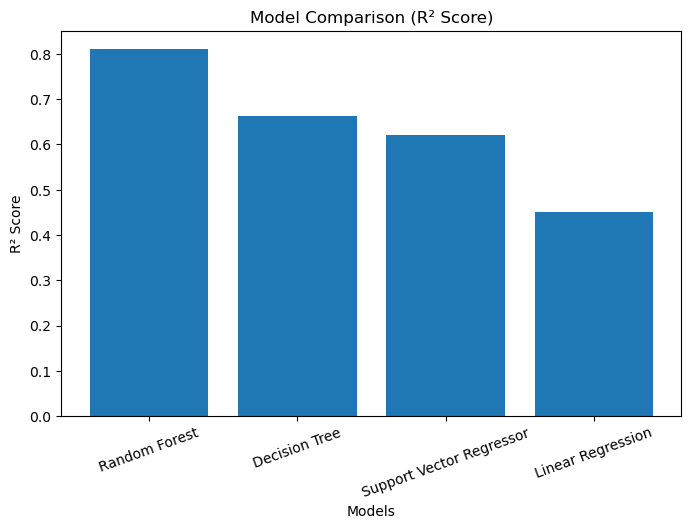

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

In [213]:
results.to_csv("model_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [219]:
# import pickle

# with open("food_delivery_model.pkl", "wb") as file:
#     print(type(deploy_model))
#     print(deploy_model.n_estimators)
#     print(deploy_model.max_depth)
#     pickle.dump(best_rf, file)

# print("Model saved successfully!")

import pickle
import os

with open("food_delivery_model.pkl", "wb") as file:
    pickle.dump(deploy_model, file)

print("Model saved successfully!")
print(type(deploy_model))
print(deploy_model.n_estimators)
print(deploy_model.max_depth)
print(f"Size: {os.path.getsize('food_delivery_model.pkl')/(1024*1024):.2f} MB")

Model saved successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>
100
20
Size: 91.66 MB


In [220]:
# from sklearn.preprocessing import LabelEncoder
# import pickle

# label_encoders = {}

# # Reload the original dataset
# original_data = pd.read_csv("train.csv")

# # Replace missing string values
# import numpy as np
# original_data = original_data.replace("NaN ", np.nan)

# # Fill missing values (same preprocessing as before)
# original_data["Delivery_person_Age"] = original_data["Delivery_person_Age"].fillna(original_data["Delivery_person_Age"].median())
# original_data["Delivery_person_Ratings"] = original_data["Delivery_person_Ratings"].fillna(original_data["Delivery_person_Ratings"].median())
# original_data["multiple_deliveries"] = original_data["multiple_deliveries"].fillna(original_data["multiple_deliveries"].mode()[0])
# original_data["Time_Orderd"] = original_data["Time_Orderd"].fillna(original_data["Time_Orderd"].mode()[0])

# categorical_cols = original_data.select_dtypes(include="object").columns

# for col in categorical_cols:
#     le = LabelEncoder()
#     original_data[col] = original_data[col].astype(str)
#     le.fit(original_data[col])
#     label_encoders[col] = le

# with open("label_encoders.pkl", "wb") as f:
#     pickle.dump(label_encoders, f)

# print("Label encoders saved successfully!")

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import pickle

label_encoders = {}

# Reload the original dataset
original_data = pd.read_csv("train.csv")

# Replace "NaN " strings with actual NaN values
original_data = original_data.replace("NaN ", np.nan)

# Convert numeric columns to numeric datatype
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]

for col in numeric_cols:
    original_data[col] = pd.to_numeric(original_data[col], errors="coerce")

# Fill missing values
original_data["Delivery_person_Age"].fillna(
    original_data["Delivery_person_Age"].median(),
    inplace=True
)

original_data["Delivery_person_Ratings"].fillna(
    original_data["Delivery_person_Ratings"].median(),
    inplace=True
)

original_data["multiple_deliveries"].fillna(
    original_data["multiple_deliveries"].mode()[0],
    inplace=True
)

original_data["Time_Orderd"].fillna(
    original_data["Time_Orderd"].mode()[0],
    inplace=True
)

# Create Label Encoders
categorical_cols = original_data.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    original_data[col] = original_data[col].astype(str)
    le.fit(original_data[col])
    label_encoders[col] = le

# Save Label Encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("✅ Label encoders saved successfully!")

✅ Label encoders saved successfully!


In [221]:
print(X.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Order_Day', 'Order_Month', 'Order_Weekday', 'Distance_km', 'Order_Hour', 'Pickup_Time_Minutes']


In [222]:
import os

print(os.getcwd())
print(os.path.abspath("food_delivery_model.pkl"))
print(os.path.getsize("food_delivery_model.pkl") / (1024 * 1024))

C:\Users\sejal\Machine Learning\Machine Learning\Projects\ Food Delivery Time Prediction
C:\Users\sejal\Machine Learning\Machine Learning\Projects\ Food Delivery Time Prediction\food_delivery_model.pkl
91.65721130371094


In [223]:
import os
print(os.path.getsize("food_delivery_model.pkl") / (1024 * 1024))

91.65721130371094
